In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context
from tqdm import tqdm
import os
from joblib import Parallel, delayed

import seaborn as sns
import pickle

In [2]:
data = pd.read_pickle(r'..\results\dann\common_genes\pooled_features_normalized_data_weighted_dynamic_lambda.pkl')
labels = pd.read_pickle(r'..\results\dann\common_genes\pooled_labels.pkl')
experiment = pd.read_pickle(r'..\results\dann\common_genes\pooled_experiments.pkl')
tissue_id = pd.read_pickle(r'..\results\dann\common_genes\pooled_tissue_id.pkl')

In [3]:
adata = sc.AnnData(np.concatenate(data, axis=0))
adata.obs['labels'] = labels
adata.obs['experiment'] = experiment
adata.obs['tissue_id'] = tissue_id

In [4]:
sc.pp.neighbors(adata)

c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 300 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
sc.tl.umap(adata)
sc.tl.tsne(adata)

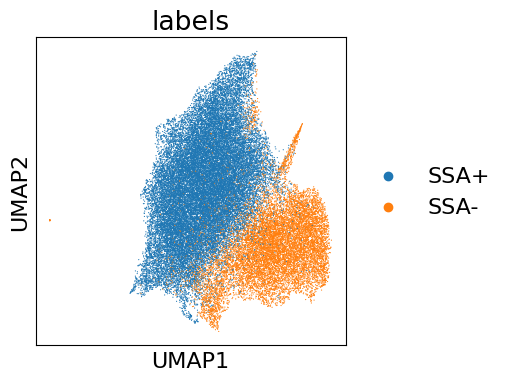

In [9]:
with rc_context({'figure.figsize':(4,4), 'font.size':16}):
    sc.pl.umap(adata, color='labels', save='_TNS_labels.png')

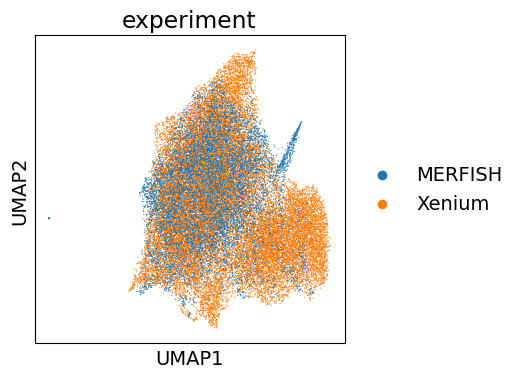

In [10]:
with rc_context({'figure.figsize':(4,4), 'font.size':14}):
    sc.pl.umap(adata, color='experiment', save='_TNS_experiment.png')

In [11]:
adata.write_h5ad(r'..\results\dann\common_genes\merfish_xenium_integration.h5ad')

In [2]:
adata = sc.read_h5ad(r'..\results\dann\common_genes\merfish_xenium_integration.h5ad')

In [12]:
embedding_observation = pd.read_csv(r'..\..\..\nanostring_xenium_comp\results\graph_classification_v5\xenium\xenium_graph_embedding_normalized_data_obs.csv')

In [15]:
sub_adata = adata[adata.obs['experiment']=='Xenium'].copy()
sub_adata.obs['leiden'] = embedding_observation['leiden'].tolist()
sub_adata.obs['leiden'] = sub_adata.obs['leiden'].astype('category')

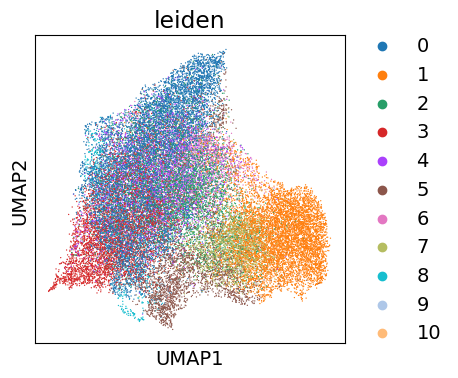

In [18]:
with rc_context({'figure.figsize':(4,4), 'font.size':14}):
    sc.pl.umap(sub_adata, color='leiden', save='_xenium_TNS.png')

# Extend xenium tns to merfish using KNN classifier

In [3]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(sub_adata.X, sub_adata.obs['leiden'].tolist())
predictions = knn.predict(adata[adata.obs['experiment']=='MERFISH'].X)

In [4]:
merfish_sub_adata = adata[adata.obs['experiment']=='MERFISH'].copy()

In [ ]:
merfish_sub_adata.obs['leiden'] = predictions
merfish_sub_adata.obs['leiden'] = merfish_sub_adata.obs['leiden'].astype('category')

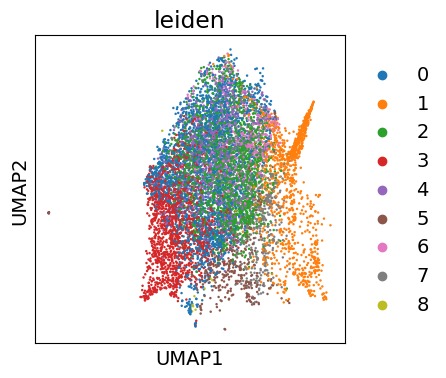

In [22]:
with rc_context({'figure.figsize':(4,4), 'font.size':14}):
    sc.pl.umap(merfish_sub_adata, color='leiden', save='_merfish_TNS.png')

In [24]:
sub_adata.write_h5ad(r'..\results\dann\common_genes\DANN_xenium_embedding.h5ad')
merfish_sub_adata.write_h5ad(r'..\results\dann\common_genes\DANN_merfish_embedding.h5ad')

In [ ]:
merfish_sub_adata = sc.read_h5ad(r'..\results\dann\common_genes\DANN_merfish_embedding.h5ad')

In [9]:
with open(r'..\results\dann\common_genes\embedding_leiden_colors.pkl', 'wb') as f:
    pickle.dump(merfish_sub_adata.uns['leiden_colors'], f)

# Composition of each cluster

## serological labels

In [6]:
observation = merfish_sub_adata.obs.copy()

In [7]:
observation.to_csv(r'..\results\dann\common_genes\MERFISH_embedding_observation.csv')

In [206]:
df = observation.groupby('leiden')['labels'].value_counts().unstack()#reset_index(name='Count')

C:\Users\zfang38\AppData\Local\Temp\ipykernel_242540\661090057.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = observation.groupby('leiden')['labels'].value_counts().unstack()#reset_index(name='Count')


In [33]:
out_dir = r'..\figures\dann\cluster_composition'

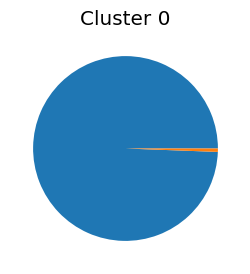

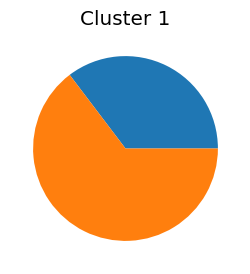

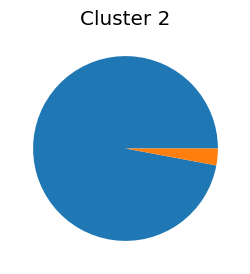

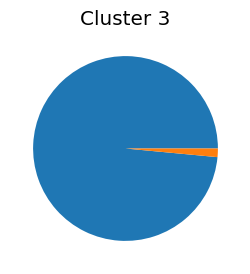

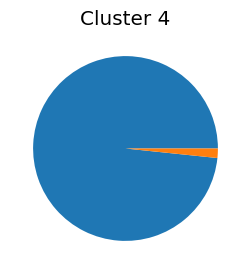

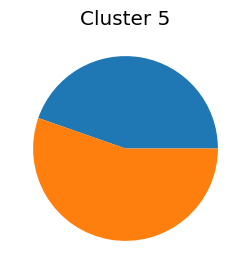

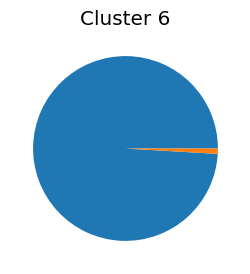

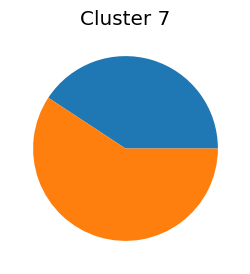

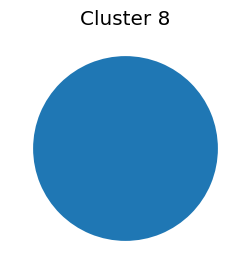

In [36]:
for i in range(9):
    series = df.loc[i]
    with rc_context({'figure.figsize':(3,3), 'font.size':12}):
        fig, ax = plt.subplots()
        series.plot.pie(
            ax = ax,
            fontsize = 10,
            colors=['#1f77b4' if label == 'SSA+' else '#ff7f0e' for label in ['SSA+', 'SSA-']],
            labels=None,
            title=f'Cluster {i}'
        )
        ax.set_ylabel('')
        plt.savefig(os.path.join(out_dir, f'merfish_cluster_{i}_ssa_composition.png'))
        plt.show()

## cell types

In [49]:
cell_type_colors = pd.read_pickle(r"..\results\merscope_colors.pkl")

In [89]:
def count_neighborhood(neighborhood, annotation):
    unique_cells = np.unique(neighborhood)
    sub_df = annotation[annotation['cell'].isin(unique_cells)]
    cell_types = sub_df['cell_type']
    return cell_types.value_counts()

In [103]:
in_dir = r'..\results\stromal_neighborhoods'
subgraphs_tissue = {}
subgraphs_tissue['7289'] = pd.read_pickle(os.path.join(in_dir, 'sub_graphs_R1_7289.pkl'))
subgraphs_tissue['7295'] = pd.read_pickle(os.path.join(in_dir, 'sub_graphs_R2_7295.pkl'))
subgraphs_tissue['7320'] = pd.read_pickle(os.path.join(in_dir, 'sub_graphs_R3_7320.pkl'))
subgraphs_tissue['159'] = pd.read_pickle(os.path.join(in_dir, 'sub_graphs_R8_159.pkl'))
subgraphs_tissue['163'] = pd.read_pickle(os.path.join(in_dir, 'sub_graphs_R9_163.pkl'))

In [104]:
in_dir = r'..\results'
annotations_tissue = {}
annotations_tissue['7289'] = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R1_7289_annotated_filtered.csv'))
annotations_tissue['7295'] = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R2_7295_annotated_filtered.csv'))
annotations_tissue['7320'] = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R3_7320_annotated_filtered.csv'))
annotations_tissue['159'] = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R8_159_annotated_filtered.csv'))
annotations_tissue['163'] = pd.read_csv(os.path.join(in_dir, '202512291513_20251230msg1p140_VMSC11512_region_R9_163_annotated_filtered.csv'))

In [118]:
for k in annotations_tissue.keys():
    annotations_tissue[k].index = annotations_tissue[k]['cell'].tolist()

In [53]:
cell_type_counts = {}
for k in cell_type_colors.keys():
    cell_type_counts[k] = []

for k in annotations_tissue.keys():
    for item in tqdm(subgraphs_tissue[k]):
        temp = count_neighborhood(item, annotations_tissue[k])
        for t in cell_type_colors.keys():
            if t in temp.index:
                cell_type_counts[t].append(temp[t])
            else:
                cell_type_counts[t].append(0)

100%|██████████| 542/542 [00:00<00:00, 2426.97it/s]


In [55]:
cell_composition = pd.DataFrame(cell_type_counts)
cell_composition.columns = cell_type_counts.keys()

In [56]:
cell_composition = cell_composition / cell_composition.sum(axis=1).values[:,None]

In [57]:
cell_composition['cluster'] = merfish_sub_adata.obs['leiden'].tolist()

In [58]:
cell_composition.to_csv(r'..\results\dann\common_genes\cell_composition.csv', index=False)

In [59]:
mean_composition = cell_composition.groupby('cluster').mean()

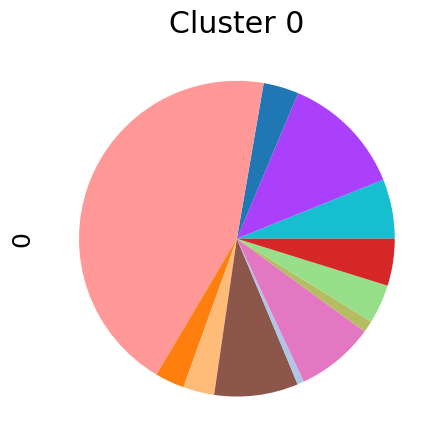

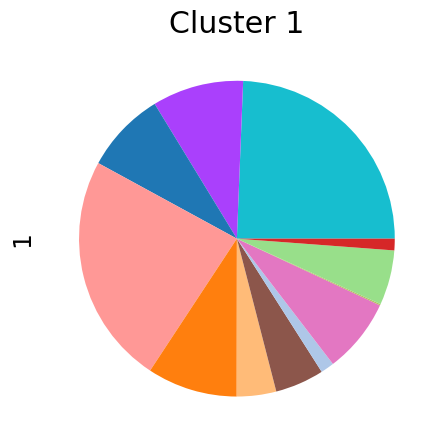

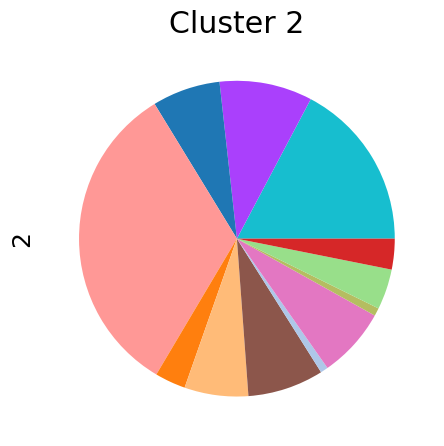

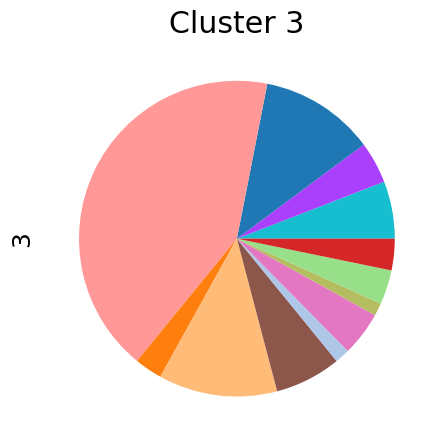

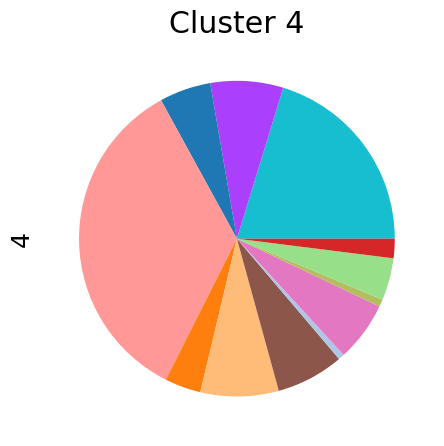

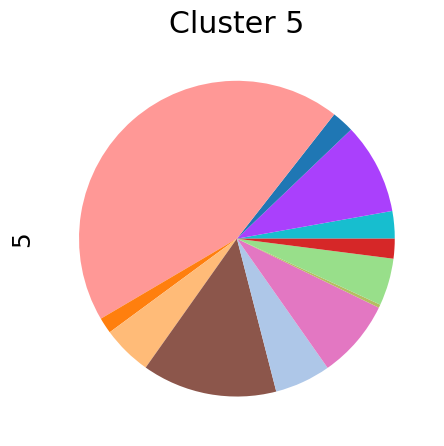

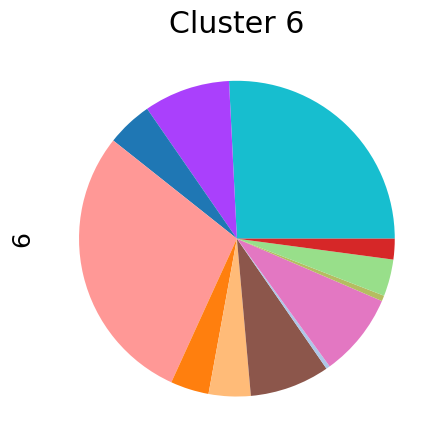

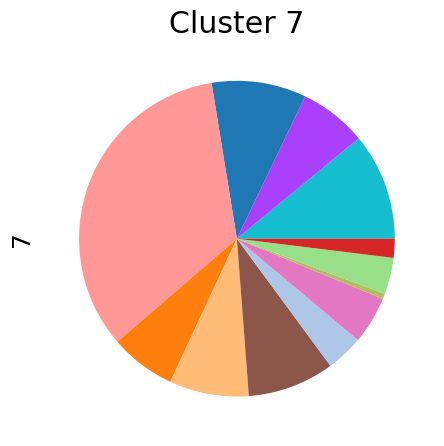

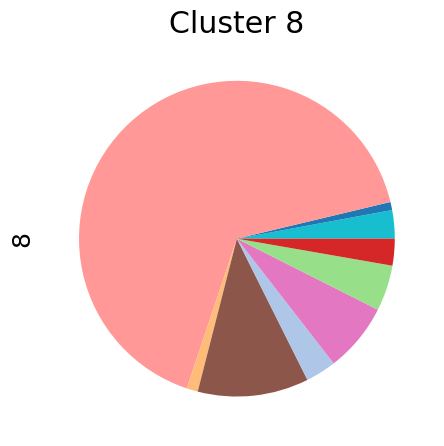

In [60]:
out_dir = r'..\figures\dann\cluster_composition'
for item in mean_composition.index:
    with rc_context({'font.size':18}):
        mean_composition.loc[item].plot.pie(
            colors=[cell_type_colors[cell] for cell in mean_composition.columns],
            legend=False,
            title=f'Cluster {item}',
            labels=None  # Remove labels from each wedge
        )
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f'merfish_cluster_{item}_cell_type_composition.png'))
        plt.show()

## stromal subtype population

In [166]:
stromal_adata_obs = pd.read_csv(r'..\results\stromal_adata_obs.csv')

In [170]:
stromal_subtype_colors = ['#7570b3', '#e6ab02', '#1b9e77', '#e7298a', '#d95f02', '#66a61e']

In [172]:
observation['stromal_subtypes'] = stromal_adata_obs['leiden'].tolist()

In [175]:
df = observation.groupby('leiden')['stromal_subtypes'].value_counts().unstack()#reset_index(name='Count')

C:\Users\zfang38\AppData\Local\Temp\ipykernel_242540\378981411.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = observation.groupby('leiden')['stromal_subtypes'].value_counts().unstack()#reset_index(name='Count')


In [176]:
out_dir = r'..\figures\dann\cluster_composition'

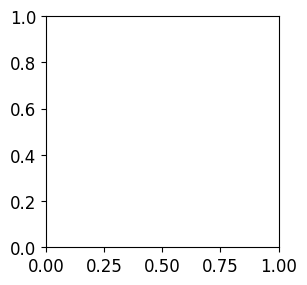

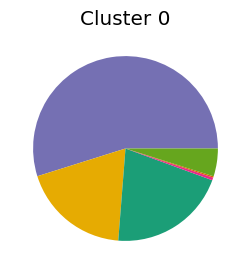

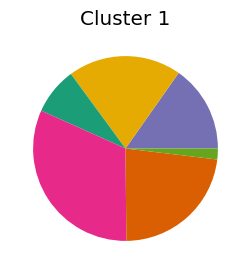

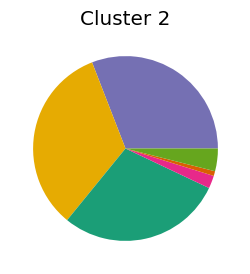

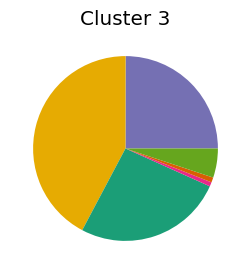

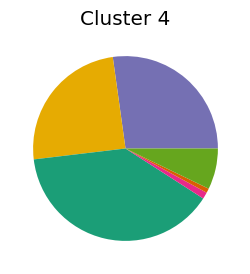

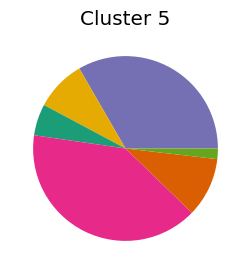

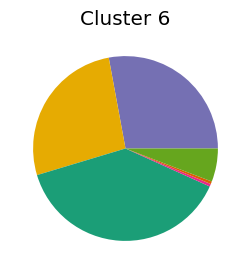

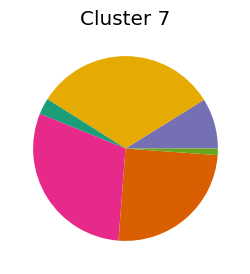

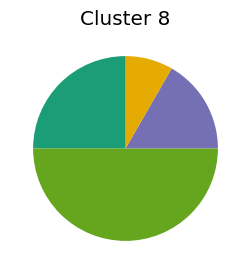

In [181]:
for i in range(9):
    series = df.loc[i]
    with rc_context({'figure.figsize':(3,3), 'font.size':12}):
        fig, ax = plt.subplots()
        series.plot.pie(
            ax = ax,
            fontsize = 10,
            colors=[stromal_subtype_colors[int(l)] for l in df.columns],
            labels=None,
            title=f'Cluster {i}'
        )
        ax.set_ylabel('')
        plt.savefig(os.path.join(out_dir, f'merfish_cluster_{i}_stromal_composition.png'))
        plt.show()

In [182]:
df.to_csv(r'..\results\dann\common_genes\stromal_subtype_composition.csv')

## combined stacked plots

In [183]:
ssa_composition = observation.groupby('leiden')['labels'].value_counts().unstack()

C:\Users\zfang38\AppData\Local\Temp\ipykernel_242540\3812132160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ssa_composition = observation.groupby('leiden')['labels'].value_counts().unstack()


In [193]:
ssa_colors = ['#1f77b4', '#ff7f0e']

In [196]:
out_dir = r'..\figures\dann\cluster_composition'

In [200]:
rename_mapper = {0:'IFNg stimulaated', 1:'Peri-vascular', 2:'Inflammatory', 3:'Myofibroblast', 4:'Immune associated', 5:'Vascular'}

In [202]:
temp.rename(columns=rename_mapper, inplace=True)

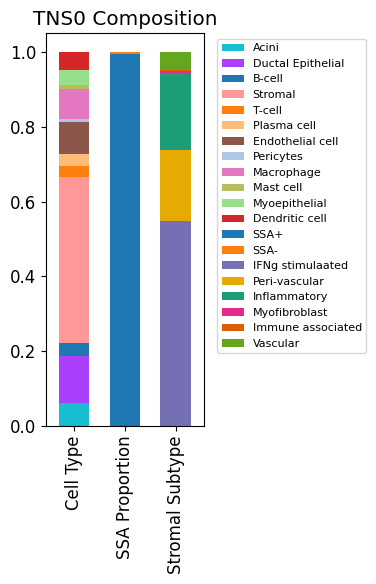

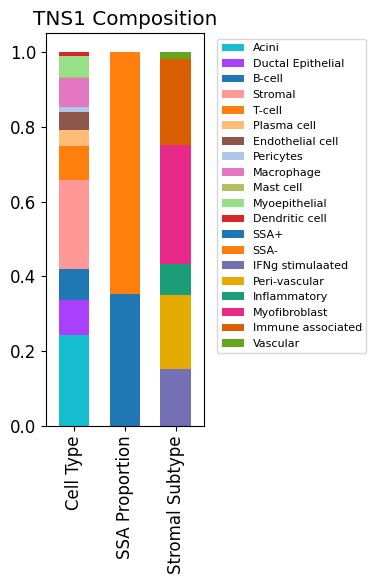

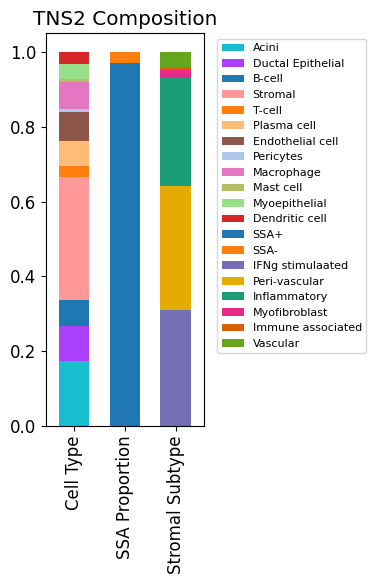

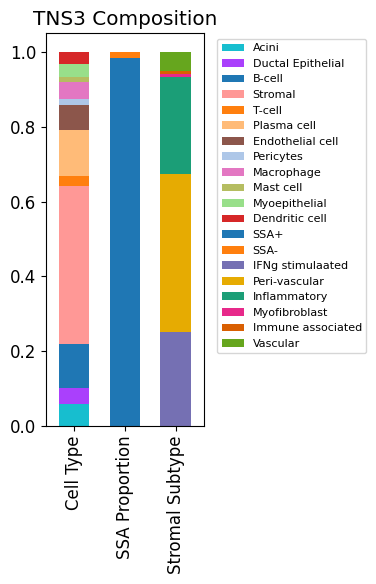

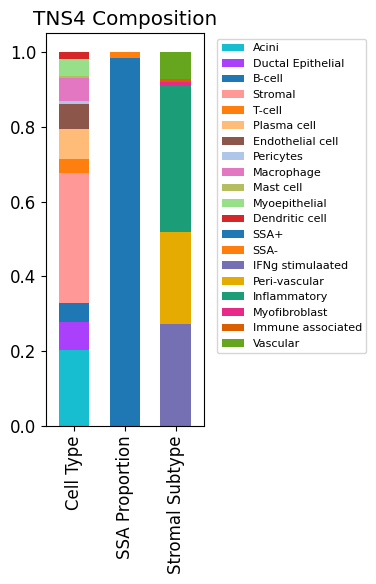

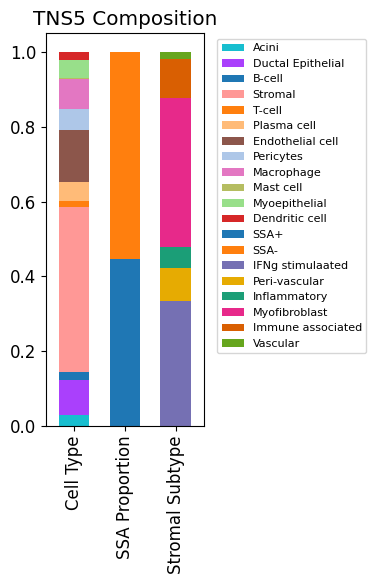

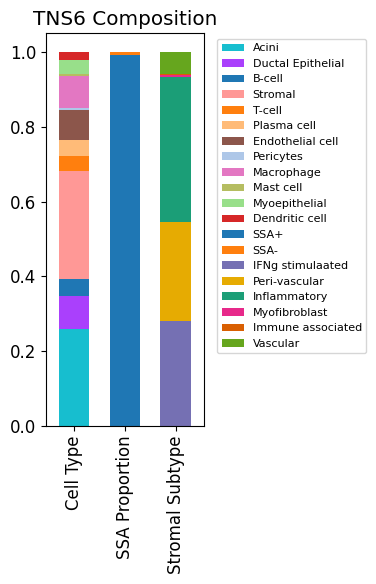

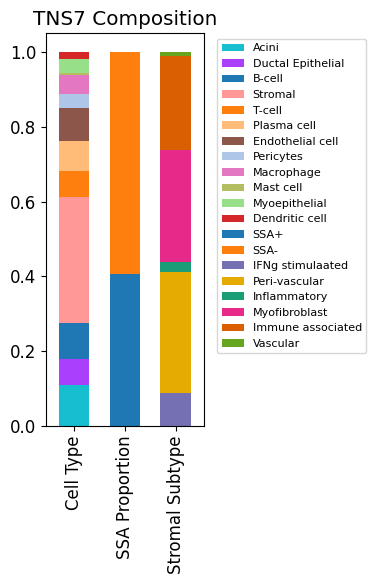

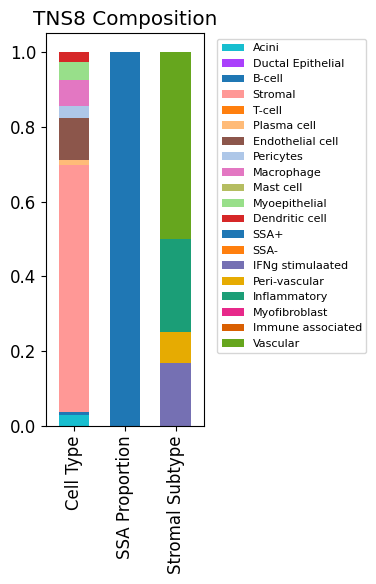

In [204]:
for i in range(9):
    temp = pd.concat([mean_composition.loc[i].to_frame().T,
                      ssa_composition.loc[i].to_frame().T,
                      df.loc[i].to_frame().T])
    temp.index = ['Cell Type', 'SSA Proportion', 'Stromal Subtype']
    temp.fillna(0, inplace=True)
    temp = temp / temp.sum(axis=1).values[:,None]
    temp.rename(columns=rename_mapper, inplace=True)
    with rc_context({'font.size': 12}):
        temp.plot(kind='bar', stacked=True, figsize=(4,6), width=0.6,
                  color=list(cell_type_colors.values())+ssa_colors+stromal_subtype_colors)
        plt.title(f'TNS{i} Composition')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f'TNS{i}_combined_composition.png'))
        plt.show()

# Markers of each cell type per TNS

In [91]:
exp_dfs_tissue = {}
exp_dfs_tissue['7289'] = pd.read_csv(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R1\cell_by_gene.csv')
exp_dfs_tissue['7295'] = pd.read_csv(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R2\cell_by_gene.csv')
exp_dfs_tissue['7320'] = pd.read_csv(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R3\cell_by_gene.csv')
exp_dfs_tissue['159'] = pd.read_csv(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R8\cell_by_gene.csv')
exp_dfs_tissue['163'] = pd.read_csv(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R9\cell_by_gene.csv')

In [103]:
for k in exp_dfs_tissue.keys():
    exp_dfs_tissue[k].index = exp_dfs_tissue[k]['cell'].tolist()
    exp_dfs_tissue[k] = exp_dfs_tissue[k].iloc[:,1:141]

In [104]:
neighborhood_nodes = {}
for k in subgraphs_tissue.keys():
    neighborhood_nodes[k] = []
    for item in subgraphs_tissue[k]:
        neighborhood_nodes[k].append(item)

In [127]:
cell_type_markers = {'Endothelial cell': ['PLVAP', 'PECAM1', 'COL15A1', 'CSF1'],
                     'Pericytes': ['NOTCH3', 'MCAM', 'IGFBP7', 'CSF1'],
                     'Stromal': ['COL1A1', 'COL3A1', 'CXCL14', 'S100A1', 'CSF1', 'MYH11', 'LUM'],
                     'B-cell': ['TNFRSF13C', 'MS4A1', 'CD79A', 'CD19', 'IFI44L'],
                     'Plasma cell': ['JCHAIN', 'MZB1', 'DERL3'],
                     'Mast cell': ['GATA2', 'CPA3', 'MS4A2', 'KIT'],
                     'Acini': ['AQP5', 'XBP1', 'CEACAM6'],
                     'Myoepithelial': ['ACTA2', 'MYH11', 'MCAM'],
                     'Dendritic cell': ['CSF1R', 'MPEG1', 'CD14', 'ITGAX', 'IFI44L'],
                     'T-cell': ['CD3E', 'CD2', 'TGFB1', 'CD4', 'GZMK', 'CD8A', 'CD8B', 'TCF7', 'IFI44L'],
                     'Ductal Epithelial': ['EGFR', 'CX3CL1', 'BARX2', 'EGFR'],
                     'Macrophage': ['CD14', 'CSF1R', 'CX3CL1', 'ITGAX', 'CD163'],
                     'other': ['CD74', 'XBP1', 'CD79A']
                    }

In [128]:
def excluding_genes(cell_type):
    genes_to_exclude = []
    for k, v in cell_type_markers.items():
        if k != cell_type:
            genes_to_exclude.extend(v)
    return genes_to_exclude

## all cell type combined analysis

In [129]:
def cell_types_in_cluster(graphs, annotations, exp_df, cell_types):
    result = {}
    for item in cell_types:
        result[item] = []
    for item in graphs:
        cells = np.unique(item)
        temp = annotations.loc[cells]
        for item in cell_types:
            if item in temp['cell_types'].values:
                cell_ids = temp[temp['cell_types'] == item].index.tolist()
                result[item].append(exp_df.loc[cell_ids])
    return result

In [130]:
tissue_celltype = {}
for k in annotations_tissue.keys():
    for c in cell_type_colors.keys():
        if not c in tissue_celltype.keys():
            tissue_celltype[c] = {}
        tissue_celltype[c][k] = annotations_tissue[k][annotations_tissue[k]['cell_type'] == c]

In [131]:
out_dir = r'..\results\dann\common_genes\pathways\gene_sets'

In [132]:
observation = merfish_sub_adata.obs.copy()

In [137]:
for l in tqdm(range(9)):
    cluster_graphs = {}
    for k in subgraphs_tissue.keys():
        sub_df = observation[observation['leiden'] == l].copy()
        sub_df = observation[observation['tissue_id'] == 'MERFISH_'+k].copy()
        idx = np.where(sub_df['leiden'] == l)[0]
        cluster_graphs[k] = [subgraphs_tissue[k][i] for i in idx]

    cluster_exp = []
    cluster_cell_types = []
    for k in cluster_graphs:
        for item in cluster_graphs[k]:
            nodes = np.unique(item)
            cluster_exp.append(exp_dfs_tissue[k].loc[nodes])
            cluster_cell_types.extend(annotations_tissue[k].loc[nodes]['cell_type'].tolist())
    cluster_exp = pd.concat(cluster_exp, axis=0)
    cluster_exp['cell_type'] = cluster_cell_types

    for c in tqdm(tissue_celltype.keys()):
        if c not in cluster_exp['cell_type'].unique():
            continue
        outside_c = {}
        for k in tissue_celltype[c].keys():
            outside_c[k] = cluster_exp[~cluster_exp['cell_type'].isin(tissue_celltype[c][k]['cell_type'].unique())].copy()
        outside_c_exp = []
        for k in outside_c.keys():
            outside_c_exp.append(outside_c[k].drop(columns=['cell_type']))
        
        if len(outside_c_exp) == 0 or len(cluster_exp[cluster_exp['cell_type']==c]):
            continue
        outside_c_exp = pd.concat(outside_c_exp, axis=0)
        cluster_outside_c = pd.concat([outside_c_exp, cluster_exp[cluster_exp['cell_type']==c]], axis=0)
        cluster_c_adata = sc.AnnData(cluster_outside_c.values[:,:140].astype('float'))
        cluster_c_adata.var_names = cluster_outside_c.columns.tolist()[:140]
        cluster_c_adata.obs['neighborhood cluster'] = pd.Categorical(['out']*len(outside_c_exp) + [l]*len(cluster_exp[cluster_exp['cell_type']==c]), categories=['out', l])
        genes_to_exclude = excluding_genes(c)
        cluster_c_adata = cluster_c_adata[:, ~cluster_c_adata.var_names.isin(genes_to_exclude)].copy()
        sc.pp.log1p(cluster_c_adata)
        sc.tl.rank_genes_groups(cluster_c_adata, groupby='neighborhood cluster', method='wilcoxon')
        # save top 20 genes of cluster l in a .txt file
        result = cluster_c_adata.uns['rank_genes_groups']
        markers = result['names'][:20][str(l)]
        with open(os.path.join(out_dir, 'cluster_'+str(l)+'_'+c+'.txt'), 'w') as f:
            for i in range(20):
                f.write(markers[i] + '\n')
            f.write('\n')

100%|██████████| 9/9 [00:10<00:00,  1.11s/it]


In [164]:
l = 8
cluster_graphs = {}
for k in subgraphs_tissue.keys():
    sub_df = observation[observation['leiden'] == l].copy()
    sub_df = observation[observation['tissue_id'] == 'MERFISH_'+k].copy()
    idx = np.where(sub_df['leiden'] == l)[0]
    cluster_graphs[k] = [subgraphs_tissue[k][i] for i in idx]

cluster_exp = []
cluster_cell_types = []
for k in cluster_graphs:
    for item in cluster_graphs[k]:
        nodes = np.unique(item)
        cluster_exp.append(exp_dfs_tissue[k].loc[nodes])
        cluster_cell_types.extend(annotations_tissue[k].loc[nodes]['cell_type'].tolist())
cluster_exp = pd.concat(cluster_exp, axis=0)
cluster_exp['cell_type'] = cluster_cell_types

# for c in tqdm(tissue_celltype.keys()):
c = 'Plasma cell'
# if c not in cluster_exp['cell_type'].unique():
#     continue
outside_c = {}
for k in tissue_celltype[c].keys():
    outside_c[k] = cluster_exp[~cluster_exp['cell_type'].isin(tissue_celltype[c][k]['cell_type'].unique())].copy()
outside_c_exp = []
for k in outside_c.keys():
    outside_c_exp.append(outside_c[k].drop(columns=['cell_type']))

# if len(outside_c_exp) == 0 or len(cluster_exp[cluster_exp['cell_type']==c]):
#     continue
outside_c_exp = pd.concat(outside_c_exp, axis=0)
cluster_outside_c = pd.concat([outside_c_exp, cluster_exp[cluster_exp['cell_type']==c]], axis=0)
cluster_c_adata = sc.AnnData(cluster_outside_c.values[:,:140].astype('float'))
cluster_c_adata.var_names = cluster_outside_c.columns.tolist()[:140]
cluster_c_adata.obs['neighborhood cluster'] = pd.Categorical(['out']*len(outside_c_exp) + [l]*len(cluster_exp[cluster_exp['cell_type']==c]), categories=['out', l])
genes_to_exclude = excluding_genes(c)
cluster_c_adata = cluster_c_adata[:, ~cluster_c_adata.var_names.isin(genes_to_exclude)].copy()
sc.pp.log1p(cluster_c_adata)
sc.tl.rank_genes_groups(cluster_c_adata, groupby='neighborhood cluster', method='wilcoxon')
# save top 20 genes of cluster l in a .txt file
result = cluster_c_adata.uns['rank_genes_groups']
markers = result['names'][:20][str(l)]
with open(os.path.join(out_dir, 'cluster_'+str(l)+'_'+c+'.txt'), 'w') as f:
    for i in range(20):
        f.write(markers[i] + '\n')
    f.write('\n')

In [165]:
markers

array(['MZB1', 'JCHAIN', 'ANGPTL7', 'IFI27L2', 'RPL15', 'CCL28', 'NF1',
       'NONO', 'FCMR', 'RPS10', 'NCAM1', 'TNN', 'CXCR4', 'SEMA3C',
       'CCL19', 'HPGDS', 'DERL3', 'WDR72', 'SLIT2', 'RPS26'], dtype=object)

# Plotting examples

In [97]:
from shapely import wkb
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches

## plot by tns

In [98]:
out_dir = r'..\figures\dann'

In [99]:
boundary = pd.read_parquet(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R1\cell_boundaries.parquet')
transcripts = pd.read_csv(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R1\detected_transcripts.csv', index_col=0)

In [106]:
tissue = 'MERFISH_7289'

In [ ]:
# cluster = 7

In [ ]:
# tissue_sub_df = merfish_sub_adata.obs[merfish_sub_adata.obs['tissue_id']==tissue]
# leiden_sub_df = tissue_sub_df[tissue_sub_df['leiden']==cluster]

In [ ]:
# leiden_sub_df.shape

(108, 4)

In [108]:
# graph_idx = leiden_sub_df.index.tolist()[50]
# graph_idx = np.where(tissue_sub_df.index.to_numpy() == graph_idx)[0][0]

In [109]:
graph_idx = 859

In [110]:
graph_to_plot = subgraphs_tissue[tissue.split('_')[1]][graph_idx]
annotation = annotations_tissue[tissue.split('_')[1]]

In [111]:
nodes = np.unique(graph_to_plot)

In [112]:
boundary_sub = boundary[boundary['EntityID'].isin(nodes)]
boundary_sub = boundary_sub[boundary_sub['ZIndex'] == 3]

transcripts_sub = transcripts[transcripts['cell_id'].isin(nodes)]

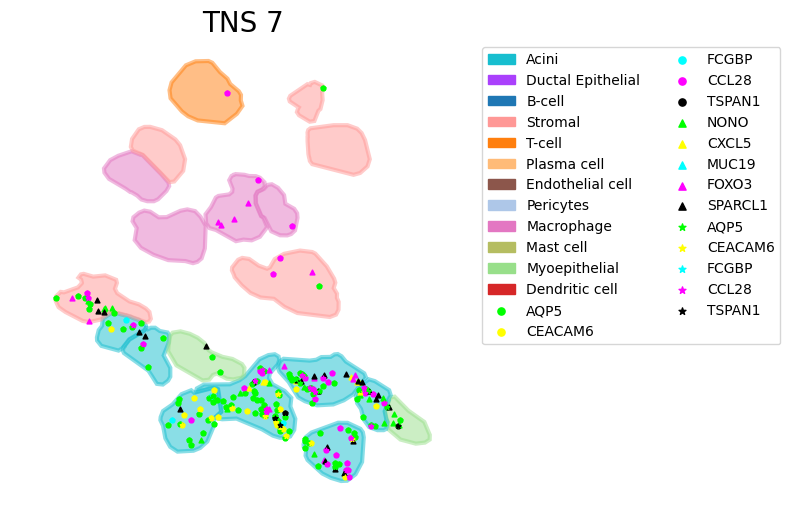

In [259]:
markers_set1 = ['AQP5', 'CEACAM6', 'FCGBP', 'CCL28', 'TSPAN1']
markers_set2 = ['NONO', 'CXCL5', 'MUC19', 'FOXO3', 'SPARCL1']
markers_set3 = ['NF1', 'JUN', 'RPL15', 'MYCN', 'NFKB1']

fig, ax = plt.subplots(1, 1, figsize=(6,6))

shape_by_type = {}
for cell_id in nodes:
    cell_shape = boundary_sub[boundary_sub['EntityID'] == cell_id]
    geom = wkb.loads(cell_shape['Geometry'].tolist()[0])
    for poly in geom.geoms:
        coords = list(poly.exterior.coords)
    coords = np.array(coords)
    color = cell_type_colors[annotation[annotation['cell']==cell_shape['EntityID'].tolist()[0]]['cell_type'].tolist()[0]]
    polygon = Polygon(coords, closed=True, edgecolor=color, facecolor=color, lw=3, alpha=0.5)
    ax.add_patch(polygon)
    if annotation[annotation['cell']==cell_id]['cell_type'].values[0] not in shape_by_type.keys():
        shape_by_type[annotation[annotation['cell']==cell_id]['cell_type'].values[0]] = []
    shape_by_type[annotation[annotation['cell']==cell_id]['cell_type'].values[0]].append(polygon)

colors = ['#00ff00', '#ffff00', '#00ffff', '#ff00ff', '#000000']
markers = markers_set1
for i, gene in enumerate(markers):
    to_plot = transcripts_sub[transcripts_sub['gene'] == gene]
    if len(to_plot)>0:
        x = to_plot['global_x'].values
        y = to_plot['global_y'].values
        ax.scatter(x, y, color=colors[i], s=12, label=gene)

markers = markers_set2
for i, gene in enumerate(markers):
    to_plot = transcripts_sub[transcripts_sub['gene'] == gene]
    if len(to_plot)>0:
        x = to_plot['global_x'].values
        y = to_plot['global_y'].values
        ax.scatter(x, y, color=colors[i], s=12, label=gene, marker='^')

markers = markers_set1
for i, gene in enumerate(markers):
    to_plot = transcripts_sub[transcripts_sub['gene'] == gene]
    if len(to_plot)>0:
        x = to_plot['global_x'].values
        y = to_plot['global_y'].values
        ax.scatter(x, y, color=colors[i], s=12, label=gene, marker='*')

ax.set_title(f'TNS {cluster}', fontsize=20)

legend_patches = [mpatches.Patch(color=color, label=cls) for cls, color in cell_type_colors.items()]
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=10, markerscale=1.5)
ax.legend(handles=legend_patches+ax.get_legend_handles_labels()[0], loc='upper left', bbox_to_anchor=(1,1), fontsize=10, markerscale=1.5, ncol=2)
ax.axis('equal')
ax.axis('off')
plt.savefig(os.path.join(out_dir, f'neighborhood_shape-dot_TNS{cluster}_tissue_{tissue}_{graph_idx[0][0]}'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# tns0
# markers_set1 = ['MZB1', 'DERL3', 'JCHAIN', 'IFI6', 'IL10RA']
# markers_set2 = ['TNFAIP3', 'CXCR4', 'FOXO3', 'ISG15', 'IRF1']
# markers_set3 = ['STAT1', 'CCR2', 'CCR7', 'CXCR3', 'ANGPTL7']

# tns1
# markers_set1 = ['COL1A1', 'COL3A1', 'CXCL14', 'C1S', 'CXCL12']
# markers_set2 = ['C3', 'SLIT2', 'CFH', 'PDGFRA', 'FBN1']
# markers_set3 = ['FOS', 'APOE', 'LUM', 'IL11RA', 'IDO2']

# tns3
# markers_set1 = ['IL10RA', 'FOXO3', 'TNFRSF13C', 'FCGBP', 'CXCR4']
# markers_set2 = ['CCR2', 'IRF1', 'TNFAIP3', 'CCL19', 'WDR72']
# markers_set3 = ['RGS16', 'IFITM2', 'CCR7', 'ABCA10', 'BANK1']

# tns5
# markers_set1 = ['IRF9', 'APOE', 'IL10RA', 'CD163', 'CR1']
# markers_set2 = ['MLXIPL', 'IRF8', 'C3', 'FCGBP', 'IL17RA']
# markers_set3 = ['CX3CR1', 'CCR2', 'BANK1', 'RGS1', 'TUBB3']

# tns6
# markers_set1 = ['AQP5', 'CEACAM6', 'CCL28', 'FCGBP', 'TSPAN1']
# markers_set2 = ['NONO', 'IFI6', 'CXCL5', 'MUC19', 'MYCN']
# markers_set3 = ['NF1', 'NFKB1', 'FOXO3', 'RPL15', 'C1RL']

# tns7
# markers_set1 = ['AQP5', 'CEACAM6', 'FCGBP', 'CCL28', 'TSPAN1']
# markers_set2 = ['NONO', 'CXCL5', 'MUC19', 'FOXO3', 'SPARCL1']
# markers_set3 = ['NF1', 'JUN', 'RPL15', 'MYCN', 'NFKB1']

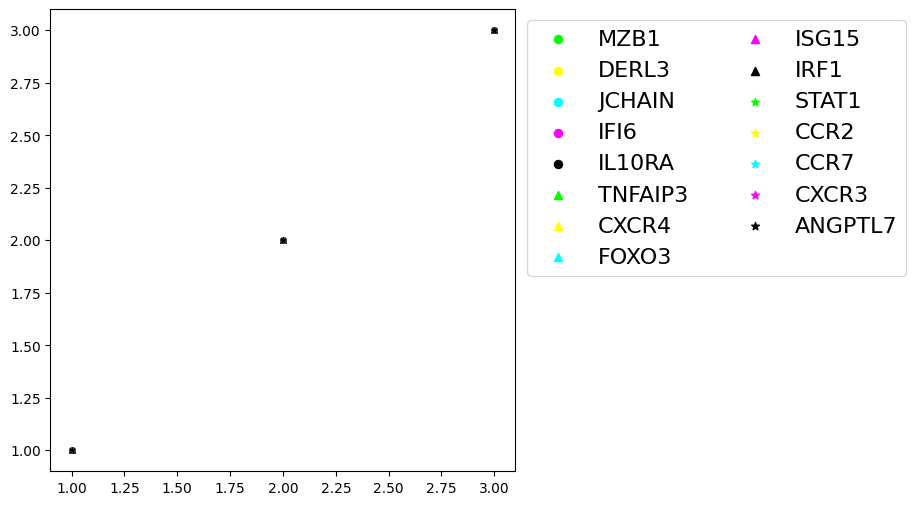

In [275]:
# plot legend only
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# cells_plotted = cell_type_colors.keys()
# cell_type_color_map = {cell_type: cell_type_colors[cell_type] for cell_type in cells_plotted}
# shape_by_type = {}
# for cell in cells_plotted:
#     cell_shape = [[1, 1], [2, 2], [3, 3], [4, 4], [5, 5]]
#     color = cell_type_color_map[cell]
#     polygon = Polygon(cell_shape, closed=True, edgecolor=color, facecolor=color, lw=3, alpha=0.5)
#     ax.add_patch(polygon)
#     if cell not in shape_by_type.keys():
#         shape_by_type[cell] = []
#     shape_by_type[cell].append(polygon)

colors = ['#00ff00', '#ffff00', '#00ffff', '#ff00ff', '#000000']
markers_set1 = ['MZB1', 'DERL3', 'JCHAIN', 'IFI6', 'IL10RA']
markers_set2 = ['TNFAIP3', 'CXCR4', 'FOXO3', 'ISG15', 'IRF1']
markers_set3 = ['STAT1', 'CCR2', 'CCR7', 'CXCR3', 'ANGPTL7']
genes_plotted = markers_set1 + markers_set2 + markers_set3
for i, gene in enumerate(markers_set1):
    if gene in genes_plotted:
        x = [1, 2, 3]
        y = [1, 2, 3]
        ax.scatter(x, y, color=colors[i], s=15, label=gene)
for i, gene in enumerate(markers_set2):
    if gene in genes_plotted:
        x = [1, 2, 3]
        y = [1, 2, 3]
        ax.scatter(x, y, color=colors[i], s=15, marker='^', label=gene)
for i, gene in enumerate(markers_set3):
    if gene in genes_plotted:
        x = [1, 2, 3]
        y = [1, 2, 3]
        ax.scatter(x, y, color=colors[i], s=15, marker='*', label=gene)
legend_patches = [mpatches.Patch(color=color, label=cls) for cls, color in cell_type_colors.items()]
ax.legend(handles=ax.get_legend_handles_labels()[0], loc='upper left', bbox_to_anchor=(1, 1), fontsize=16, markerscale=1.5, ncol=2)
plt.savefig(os.path.join(r'..\figures\dann', f'tns0_transcripts_legend.png'), dpi=300, bbox_inches='tight')
plt.show()

## plot by index

In [150]:
out_dir = r'..\figures\napari_figures\v2'

In [165]:
boundary = pd.read_parquet(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R8\cell_boundaries.parquet')
transcripts = pd.read_csv(r'..\merfish_output\202512291513_20251230msg1p140_VMSC11512\region_R8\detected_transcripts.csv', index_col=0)

In [166]:
tissue = 'MERFISH_159'

In [167]:
graph_idx = 170

In [168]:
graph_to_plot = subgraphs_tissue[tissue.split('_')[1]][graph_idx]
annotation = annotations_tissue[tissue.split('_')[1]]

In [169]:
nodes = np.unique(graph_to_plot)

In [170]:
boundary_sub = boundary[boundary['EntityID'].isin(nodes)]
boundary_sub = boundary_sub[boundary_sub['ZIndex'] == 3]

transcripts_sub = transcripts[transcripts['cell_id'].isin(nodes)]

In [171]:
cell_type_colors.values()

dict_values(['#17becf', '#aa40fc', '#1f77b4', '#ff9896', '#ff7f0e', '#ffbb78', '#8c564b', '#aec7e8', '#e377c2', '#b5bd61', '#98df8a', '#d62728'])

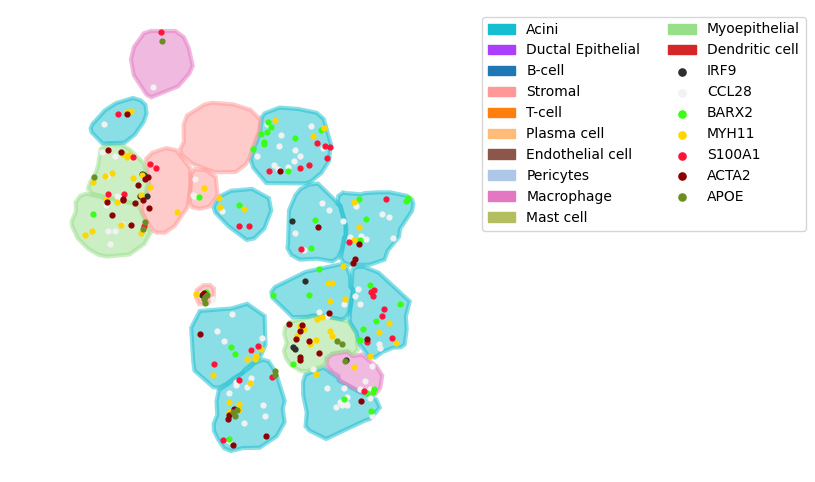

In [172]:
markers_set1 = ['IRF9','CCL28', 'BARX2', 'MYH11', 'S100A1', 'ACTA2', 'APOE']

fig, ax = plt.subplots(1, 1, figsize=(6,6))

shape_by_type = {}
for cell_id in nodes:
    cell_shape = boundary_sub[boundary_sub['EntityID'] == cell_id]
    geom = wkb.loads(cell_shape['Geometry'].tolist()[0])
    for poly in geom.geoms:
        coords = list(poly.exterior.coords)
    coords = np.array(coords)
    color = cell_type_colors[annotation[annotation['cell']==cell_shape['EntityID'].tolist()[0]]['cell_type'].tolist()[0]]
    polygon = Polygon(coords, closed=True, edgecolor=color, facecolor=color, lw=3, alpha=0.5)
    ax.add_patch(polygon)
    if annotation[annotation['cell']==cell_id]['cell_type'].values[0] not in shape_by_type.keys():
        shape_by_type[annotation[annotation['cell']==cell_id]['cell_type'].values[0]] = []
    shape_by_type[annotation[annotation['cell']==cell_id]['cell_type'].values[0]].append(polygon)

colors = ['#2e2e2e', '#f2f2f2', '#39ff14', '#ffd700', '#ff1439', '#8d0000', '#6b8e23']
markers = markers_set1
for i, gene in enumerate(markers):
    to_plot = transcripts_sub[transcripts_sub['gene'] == gene]
    if len(to_plot)>0:
        x = to_plot['global_x'].values
        y = to_plot['global_y'].values
        ax.scatter(x, y, color=colors[i], s=12, label=gene)

# markers = markers_set2
# for i, gene in enumerate(markers):
#     to_plot = transcripts_sub[transcripts_sub['gene'] == gene]
#     if len(to_plot)>0:
#         x = to_plot['global_x'].values
#         y = to_plot['global_y'].values
#         ax.scatter(x, y, color=colors[i], s=12, label=gene, marker='^')

# markers = markers_set1
# for i, gene in enumerate(markers):
#     to_plot = transcripts_sub[transcripts_sub['gene'] == gene]
#     if len(to_plot)>0:
#         x = to_plot['global_x'].values
#         y = to_plot['global_y'].values
#         ax.scatter(x, y, color=colors[i], s=12, label=gene, marker='*')

# ax.set_title(f'TNS {cluster}', fontsize=20)

legend_patches = [mpatches.Patch(color=color, label=cls) for cls, color in cell_type_colors.items()]
ax.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize=10, markerscale=1.5)
ax.legend(handles=legend_patches+ax.get_legend_handles_labels()[0], loc='upper left', bbox_to_anchor=(1,1), fontsize=10, markerscale=1.5, ncol=2)
ax.axis('equal')
ax.axis('off')
plt.savefig(os.path.join(out_dir, f'neighborhood_shape-dot_stromal-3_tissue_{tissue}_{graph_idx}'), dpi=300, bbox_inches='tight')
plt.show()

# Average composition comparison

In [5]:
merfish_mean_composition = pd.read_csv(r'..\results\dann\common_genes\cell_composition.csv')
merfish_mean_composition = merfish_mean_composition.groupby('cluster').mean()

In [6]:
xenium_mean_composition = pd.read_csv(r"Y:\coskun-lab\Zhou\12_MSG\nanostring_xenium_comp\results\graph_classification_v5\xenium\xenium_cell_type_composition_stromal_neighborhood.csv", index_col=0)
xenium_mean_composition.drop(columns=['stromal_cluster'], inplace=True)
xenium_mean_composition = xenium_mean_composition.groupby('cluster').mean()

In [7]:
merfish_mean_composition.drop(columns=['Myoepithelial'], inplace=True)

In [8]:
merfish_mean_composition = merfish_mean_composition / merfish_mean_composition.sum(axis=1).values[:,None]

In [13]:
xenium_mean_composition['Acini'] = (xenium_mean_composition['Mucous Acini'] + xenium_mean_composition['Seromucous Acini']).tolist()
xenium_mean_composition['T-cell'] = (xenium_mean_composition['CD4 T-cell'] + xenium_mean_composition['CD8 T-cell']).tolist()
xenium_mean_composition.drop(columns=['Mucous Acini', 'Seromucous Acini', 'CD4 T-cell', 'CD8 T-cell'], inplace=True)

In [21]:
xenium_mean_composition = xenium_mean_composition[merfish_mean_composition.columns.tolist()]

In [30]:
from sklearn.metrics.pairwise import cosine_distances

In [ ]:
dist_matrix = cosine_distances(xenium_mean_composition.values[:9,:], merfish_mean_composition.values[:9,:])

# dist_df = pd.DataFrame(dist_matrix, index=xenium_mean_composition.index, columns=merfish_mean_composition.index)

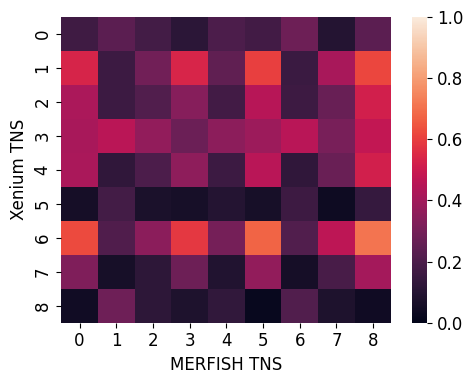

In [63]:
with rc_context({'font.size': 12}):
    fig, ax = plt.subplots(1, 1, figsize=(5,4))
    sns.heatmap(dist_matrix, ax=ax, vmin=0, vmax=1)
    ax.set_xlabel('MERFISH TNS')
    ax.set_ylabel('Xenium TNS')
    plt.tight_layout()
    plt.savefig(r'..\figures\xenium_merfish_tns_diff.png', dpi=300)
    plt.show()

In [ ]:
colors = [cell_type_colors[cell] for cell in xenium_mean_composition.columns.tolist()]

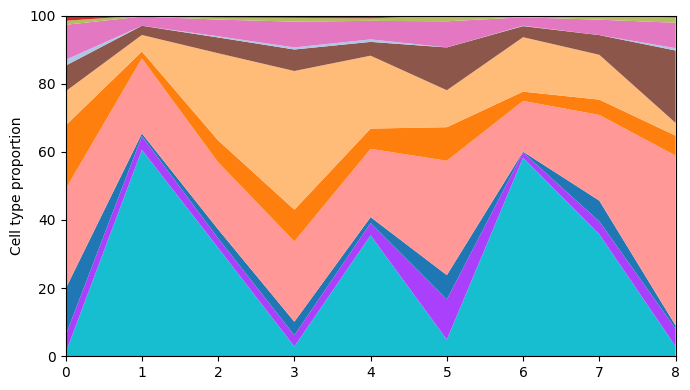

In [57]:
x = np.arange(len(merfish_mean_composition))
y = xenium_mean_composition.T.values[:,:9] * 100

fig, ax = plt.subplots(figsize=(7,4))
ax.stackplot(x, y, labels=xenium_mean_composition.columns, linewidth=0, colors=colors)

ax.set_ylim(0, 100)
ax.set_xlim(0, 8)
ax.set_ylabel("Cell type proportion")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(xenium_mean_composition.index[:9], rotation=0)
plt.tight_layout()
plt.savefig(r'..\figures\xenium_composition_stack.png', dpi=300)
plt.show()

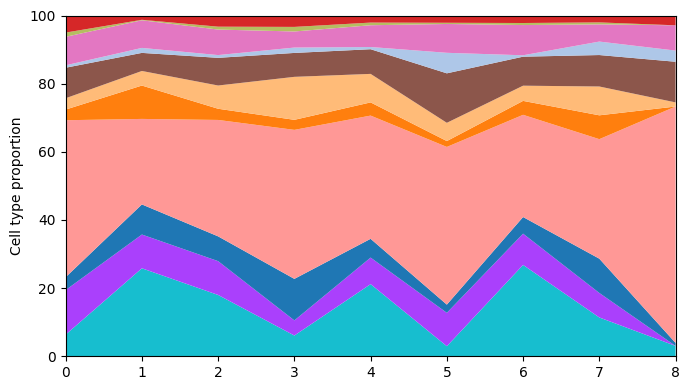

In [58]:
x = np.arange(len(merfish_mean_composition))
y = merfish_mean_composition.T.values[:,:9] * 100

fig, ax = plt.subplots(figsize=(7,4))
ax.stackplot(x, y, labels=merfish_mean_composition.columns, linewidth=0, colors=colors)

ax.set_ylim(0, 100)
ax.set_xlim(0, 8)
ax.set_ylabel("Cell type proportion")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(merfish_mean_composition.index[:9], rotation=0)

plt.tight_layout()
plt.savefig(r'..\figures\merfish_composition_stack.png', dpi=300)
plt.show()

In [64]:
matched_dist = np.diag(dist_matrix)

In [72]:
matched_dist

array([0.16624561, 0.15902738, 0.21325856, 0.27719315, 0.15997495,
       0.05931432, 0.21160724, 0.19118725, 0.03918587])

C:\Users\zfang38\AppData\Local\Temp\ipykernel_62528\65624202.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(9))


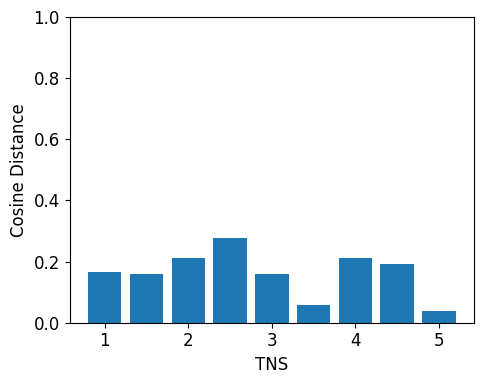

In [71]:
with rc_context({'font.size': 12}):
    fig, ax = plt.subplots(1, 1, figsize=(5,4))
    plt.bar(np.arange(9), matched_dist)
    # sns.heatmap(dist_matrix, ax=ax, vmin=0, vmax=1)
    ax.set_xlabel('TNS')
    ax.set_xticklabels(np.arange(9))
    ax.set_ylim(0,1)
    ax.set_ylabel('Cosine Distance')
    plt.tight_layout()
    plt.savefig(r'..\figures\xenium_merfish_tns_matched_diff.png', dpi=300)
    plt.show()

In [81]:
## random assign MERFISN TNS and compute cosine distance in cell type coposition
cell_composition = pd.read_csv(r'..\results\dann\common_genes\cell_composition.csv')

In [83]:
# shuffle the 'cluster' column
cell_composition['shuffled_cluster'] = cell_composition['cluster'].sample(frac=1).reset_index(drop=True)

In [84]:
shuffled_mean = cell_composition.drop(columns=['cluster']).groupby('shuffled_cluster').mean()

In [88]:
shuffled_mean.drop(columns=['Myoepithelial'], inplace=True)
shuffled_mean = shuffled_mean / shuffled_mean.sum(axis=1).values[:,None]

In [89]:
dist_matrix = cosine_distances(xenium_mean_composition.values[:9,:], shuffled_mean.values[:9,:])

In [90]:
matched_dist = np.diag(dist_matrix)

C:\Users\zfang38\AppData\Local\Temp\ipykernel_62528\785671031.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(9))


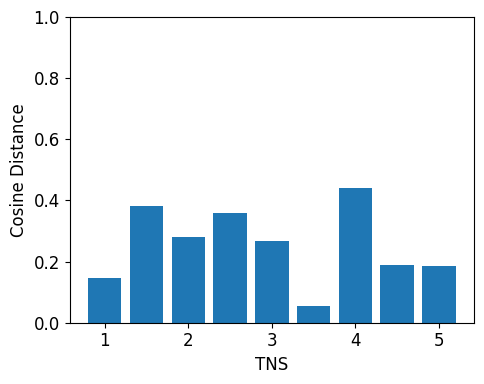

In [91]:
with rc_context({'font.size': 12}):
    fig, ax = plt.subplots(1, 1, figsize=(5,4))
    plt.bar(np.arange(9), matched_dist)
    # sns.heatmap(dist_matrix, ax=ax, vmin=0, vmax=1)
    ax.set_xlabel('TNS')
    ax.set_xticklabels(np.arange(9))
    ax.set_ylim(0,1)
    ax.set_ylabel('Cosine Distance')
    plt.tight_layout()
    plt.savefig(r'..\figures\xenium_shuffled_merfish_tns_matched_diff.png', dpi=300)
    plt.show()

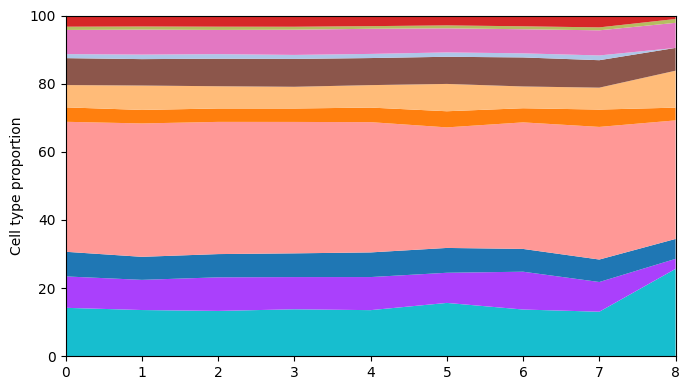

In [96]:
x = np.arange(len(shuffled_mean))
y = shuffled_mean.T.values[:,:9] * 100

fig, ax = plt.subplots(figsize=(7,4))
ax.stackplot(x, y, labels=shuffled_mean.columns, linewidth=0, colors=colors)

ax.set_ylim(0, 100)
ax.set_xlim(0, 8)
ax.set_ylabel("Cell type proportion")
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(merfish_mean_composition.index[:9], rotation=0)

plt.tight_layout()
plt.savefig(r'..\figures\merfish_shuffled_composition_stack.png', dpi=300)
plt.show()